In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report

# Load dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# ------------------ RNN MODEL ------------------
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

rnn_history = rnn_model.fit(X_train, y_train, epochs=5, batch_size=64,
                            validation_data=(X_test, y_test))

# ------------------ LSTM MODEL ------------------
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

lstm_history = lstm_model.fit(X_train, y_train, epochs=5, batch_size=64,
                              validation_data=(X_test, y_test))

# Evaluation
y_pred = (lstm_model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step
Epoch 1/5


C:\Users\Ravi Kumar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.6641 - loss: 0.5926 - val_accuracy: 0.7942 - val_loss: 0.4617
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8222 - loss: 0.3997 - val_accuracy: 0.7612 - val_loss: 0.5164
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9275 - loss: 0.1864 - val_accuracy: 0.7669 - val_loss: 0.5939
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9841 - loss: 0.0543 - val_accuracy: 0.7106 - val_loss: 0.8588
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9954 - loss: 0.0182 - val_accuracy: 0.7694 - val_loss: 0.8259
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8012 - loss: 0.4261 - val_accuracy: 0.8643 - val_loss: 0.3243
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.9018 - loss: 0.2523 - val_accuracy: 0.8666 - val_loss: 0.3373
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.9318 - loss: 0.1820 - val_accuracy: 0

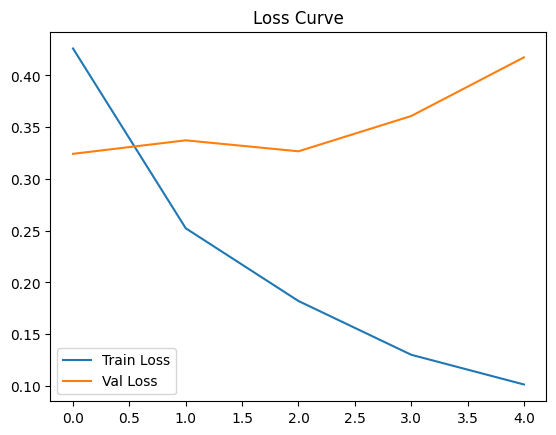

In [2]:
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

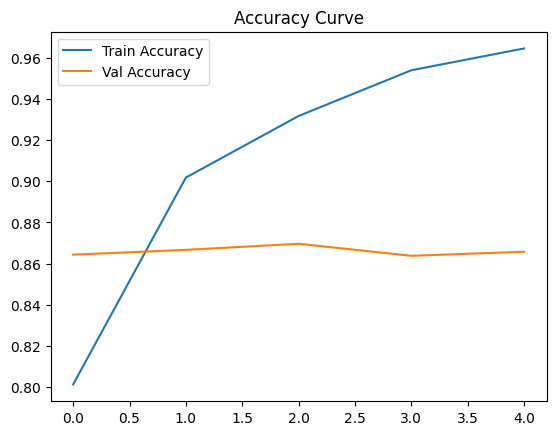

In [3]:
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()